In [1]:
# Load Packages and raw data
import pandas as pd
import numpy as np
from pathlib import Path


super_store = Path.home() / "Super_Store" / "SuperStoreUS.xlsx"

print("File Exists :", super_store.exists())

File Exists : True


In [2]:
# View avaliable sheets
xls = pd.ExcelFile(super_store)
print("Sheets in Workbook:", xls.sheet_names)

Sheets in Workbook: ['Dashboard', 'Orders', 'Returns', 'Users', 'pivot 1', 'pivot 2', 'Sheet11', 'Sheet12', 'Sheet13', 'Sheet15', 'Sheet16', 'Sheet14']


In [3]:
raw_data_a = pd.read_excel(super_store, sheet_name="Orders")

In [4]:
#Standardized Column Names
rdata_a = raw_data_a.copy()

rdata_a.columns = (
    rdata_a.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

# view data
display(rdata_a.head())
print("System A Shape:", rdata_a.shape)
print("\ncolumns:", rdata_a.columns.tolist())
print("\nInfo:")
rdata_a.info()

,customer_name,customer_id,row_id,order_priority,discount,unit_price,shipping_cost,ship_mode,customer_segment,product_category,...,region,state_or_province,city,postal_code,order_date,ship_date,profit,quantity_ordered_new,sales,order_id
0,Maureen Stout,3146,19194,Critical,0.07,3.71,1.93,Express Air,Corporate,Office Supplies,...,Central,Texas,Pharr,78577,2015-01-04,2015-01-06,6.3308,11,39.64,85850
1,Wayne Bass,2548,6525,Low,0.00,35.99,0.99,Regular Air,Small Business,Technology,...,West,California,Los Angeles,90068,2015-04-04,2015-04-11,840.0510,46,1477.57,46436
2,Joan Bowers,2551,24525,Low,0.00,35.99,0.99,Regular Air,Small Business,Technology,...,East,Pennsylvania,York,17403,2015-04-04,2015-04-11,265.9605,12,385.45,88656
3,Fred Barber,2976,19599,Medium,0.01,35.99,0.99,Regular Air,Small Business,Technology,...,Central,Wisconsin,Oak Creek,53154,2015-05-22,2015-05-23,882.4824,41,1278.96,89047
4,Paul W French,2817,24045,High,0.04,55.99,1.25,Express Air,Corporate,Technology,...,East,Ohio,Newark,43055,2015-06-01,2015-06-02,-18.3216,3,147.56,89743


System A Shape: (1952, 25)

columns: ['customer_name', 'customer_id', 'row_id', 'order_priority', 'discount', 'unit_price', 'shipping_cost', 'ship_mode', 'customer_segment', 'product_category', 'product_subcategory', 'product_container', 'product_name', 'product_base_margin', 'country', 'region', 'state_or_province', 'city', 'postal_code', 'order_date', 'ship_date', 'profit', 'quantity_ordered_new', 'sales', 'order_id']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_name         1952 non-null   object        
 1   customer_id           1952 non-null   int64         
 2   row_id                1952 non-null   int64         
 3   order_priority        1952 non-null   object        
 4   discount              1952 non-null   float64       
 5   unit_price            1952 non-null   float64      

In [5]:
# Create order-level for System A
# 1 row per order_id
system_a = (
    rdata_a
    .groupby("order_id", as_index=False)
    .agg(
        transaction_date=("order_date", "min"),
        transaction_amount=("sales", "sum"),
        state=("state_or_province", "first"),
        category=("product_category", "first")
    )
)

display(system_a.head())
print("System A (order-level) shape:", system_a.shape)
system_a.info()

,order_id,transaction_date,transaction_amount,state,category
0,359,2015-06-18,6831.37,California,Furniture
1,548,2015-03-20,5584.70,Texas,Office Supplies
2,646,2015-05-21,586.96,Texas,Office Supplies
3,962,2015-05-05,10561.20,New York,Office Supplies
4,2433,2015-02-21,43046.20,California,Technology


System A (order-level) shape: (1365, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1365 non-null   int64         
 1   transaction_date    1365 non-null   datetime64[ns]
 2   transaction_amount  1365 non-null   float64       
 3   state               1365 non-null   object        
 4   category            1365 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 53.4+ KB


In [6]:
# System B (Accoutning Ledger) from System A
ledger_b = system_a.copy()

# Changing to Accounting terminology
ledger_b = ledger_b.rename(columns={
    "transaction_date": "posting_date",
    "transaction_amount": "posting_amount"
})

# Account type
ledger_b["account_type"] = "Revenue"

display(ledger_b.head())
print("Ledger B Shape:", ledger_b.shape)
ledger_b.info()

,order_id,posting_date,posting_amount,state,category,account_type
0,359,2015-06-18,6831.37,California,Furniture,Revenue
1,548,2015-03-20,5584.70,Texas,Office Supplies,Revenue
2,646,2015-05-21,586.96,Texas,Office Supplies,Revenue
3,962,2015-05-05,10561.20,New York,Office Supplies,Revenue
4,2433,2015-02-21,43046.20,California,Technology,Revenue


Ledger B Shape: (1365, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365 entries, 0 to 1364
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1365 non-null   int64         
 1   posting_date    1365 non-null   datetime64[ns]
 2   posting_amount  1365 non-null   float64       
 3   state           1365 non-null   object        
 4   category        1365 non-null   object        
 5   account_type    1365 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 64.1+ KB


In [7]:
# Posting Delays
rng = np.random.default_rng(42)

# Assigning delay buckets
delay_bucket = rng.choice(
    ["same_day", "short_delay", "long_delay"],
    size=len(ledger_b),
    p=[0.70, 0.20, 0.10]
)

#Translate buckets into days
delay_days = np.select(
    [
        delay_bucket == "same_day",
        delay_bucket == "short_delay",
        delay_bucket == "long_delay"
    ],
    [
        0,
        rng.integers(1, 3, size=len(ledger_b)),  # 1-2 days
        rng.integers(3, 8, size=len(ledger_b))   # 3-7 days
    ]
)

#Apply delays
ledger_b["posting_date"] = ledger_b["posting_date"] + pd.to_timedelta(delay_days, unit="D")
ledger_b["sim_posting_delay_days"] = delay_days

display(ledger_b.head())
ledger_b["sim_posting_delay_days"].value_counts().sort_index()

,order_id,posting_date,posting_amount,state,category,account_type,sim_posting_delay_days
0,359,2015-06-20,6831.37,California,Furniture,Revenue,2
1,548,2015-03-20,5584.70,Texas,Office Supplies,Revenue,0
2,646,2015-05-23,586.96,Texas,Office Supplies,Revenue,2
3,962,2015-05-05,10561.20,New York,Office Supplies,Revenue,0
4,2433,2015-02-21,43046.20,California,Technology,Revenue,0


sim_posting_delay_days
0    956
1    140
2    137
3     31
4     22
5     28
6     24
7     27
Name: count, dtype: int64

In [8]:
# Missing ledger entries(3%)
missing_rate = 0.03
rng = np.random.default_rng(42)

keep_mask = rng.random(len(ledger_b)) > missing_rate
ledger_b_missing = ledger_b[keep_mask].copy()

print("Ledger rows dropped (missing postings):", len(ledger_b) - len(ledger_b_missing))
print("Ledger shape after missing entries:", ledger_b_missing.shape)

Ledger rows dropped (missing postings): 40
Ledger shape after missing entries: (1325, 7)


In [9]:
# Simulate ledger postings(1%)
duplicate_rate = 0.01

dup_sample= ledger_b_missing.sample(
    frac=duplicate_rate,
    random_state=42
)

ledger_b_dups = pd.concat(
    [ledger_b_missing, dup_sample],
    ignore_index=True
)

print("Duplicate rows added:", len(dup_sample))
print("Ledger shape after duplicates:", ledger_b_dups.shape)

Duplicate rows added: 13
Ledger shape after duplicates: (1338, 7)


In [10]:
#Amount mismatches (7%)
mismatch_rate = 0.07
rng = np.random.default_rng(42)

mismatch_mask = rng.random(len(ledger_b_dups)) < mismatch_rate

# +/- adjustments between -2% and +2%
pct_change = rng.uniform(-0.02, 0.02, size=len(ledger_b_dups))

ledger_b_dups["sim_amount_adjustment_pct"] = np.where(mismatch_mask, pct_change, 0.0)

# Posted amounts and round to cents
ledger_b_dups["posting_amount"] = (
    ledger_b_dups["posting_amount"] * (1 + ledger_b_dups["sim_amount_adjustment_pct"])
).round(2)

print("Amount mistmatches applied:", int(mismatch_mask.sum()))
ledger_b_dups[["order_id", "posting_amount", "sim_amount_adjustment_pct"]].head()

Amount mistmatches applied: 93


,order_id,posting_amount,sim_amount_adjustment_pct
0,359,6831.37,0.0
1,548,5584.70,0.0
2,646,586.96,0.0
3,962,10561.20,0.0
4,2433,43046.20,0.0


In [11]:
# System A (transaction truth)
recon_a = system_a.copy()

#System B (ledger truth with issues)
recon_b = ledger_b_dups.copy()

print("System A shape:", recon_a.shape)
print("System B shape:", recon_b.shape)

System A shape: (1365, 5)
System B shape: (1338, 8)


In [12]:
# Aggregate ledger to order level
ledger_agg = (
    recon_b
    .groupby("order_id", as_index=False)
    .agg(
        ledger_posting_date=("posting_date", "min"),
        ledger_amount=("posting_amount", "sum"),
        max_posting_delay_days=("sim_posting_delay_days", "max")
    )
)

display(ledger_agg.head())
print("Aggregated Ledger shape:", ledger_agg.shape)

,order_id,ledger_posting_date,ledger_amount,max_posting_delay_days
0,359,2015-06-20,6831.37,2
1,548,2015-03-20,5584.70,0
2,646,2015-05-23,586.96,2
3,962,2015-05-05,10561.20,0
4,2433,2015-02-21,43046.20,0


Aggregated Ledger shape: (1325, 4)


In [13]:
# Outer Join
recon_full = recon_a.merge(
    ledger_agg,
    on="order_id",
    how="outer",
    indicator=True
)

display(recon_full.head())
recon_full["_merge"].value_counts()

,order_id,transaction_date,transaction_amount,state,category,ledger_posting_date,ledger_amount,max_posting_delay_days,_merge
0,359,2015-06-18,6831.37,California,Furniture,2015-06-20,6831.37,2.0,both
1,548,2015-03-20,5584.70,Texas,Office Supplies,2015-03-20,5584.70,0.0,both
2,646,2015-05-21,586.96,Texas,Office Supplies,2015-05-23,586.96,2.0,both
3,962,2015-05-05,10561.20,New York,Office Supplies,2015-05-05,10561.20,0.0,both
4,2433,2015-02-21,43046.20,California,Technology,2015-02-21,43046.20,0.0,both


_merge
both          1325
left_only       40
right_only       0
Name: count, dtype: int64

In [14]:
# Amount Difference
recon_full["amount_diff"] = (
    recon_full["transaction_amount"] - recon_full["ledger_amount"]
)

#Absolute Difference
recon_full["abs_amount_diff"] = recon_full["amount_diff"].abs()

# Tolerance flag ($1 threshold)
tolerance = 1.00
recon_full["amount_match_flag"] = (
    recon_full["abs_amount_diff"] <= tolerance
)

display(
    recon_full[
       ["order_id", "transaction_amount", "ledger_amount",
        "amount_diff", "amount_match_flag"]
    ].head(10)
)

,order_id,transaction_amount,ledger_amount,amount_diff,amount_match_flag
0,359,6831.37,6831.37,0.000000e+00,True
1,548,5584.70,5584.70,0.000000e+00,True
2,646,586.96,586.96,0.000000e+00,True
3,962,10561.20,10561.20,0.000000e+00,True
4,2433,43046.20,43046.20,0.000000e+00,True
5,3042,351.56,351.56,0.000000e+00,True
6,3138,718.03,718.03,0.000000e+00,True
7,3332,73.97,73.97,0.000000e+00,True
8,3397,1280.63,1280.63,-2.273737e-13,True
9,3585,186.59,186.59,0.000000e+00,True


In [15]:
# Reconciliation labels
def classify_recon(row):
    if row["_merge"] == "left_only":
        return "Missing in Ledger"
    elif row["_merge"] == "right_only":
        return "Missing in Transactions"
    elif not row["amount_match_flag"]:
        return "Amount Mismatch"
    elif row["max_posting_delay_days"] > 0:
        return "Timing Difference"
    else:
        return "Fully Reconciled"

recon_full["recon_status"] = recon_full.apply(classify_recon, axis=1)

recon_full["recon_status"].value_counts()

recon_status
Fully Reconciled     865
Timing Difference    390
Amount Mismatch       70
Missing in Ledger     40
Name: count, dtype: int64

In [16]:
# Reconciliation Summary
summary = {
    "total_orders": len(recon_full),
    "fully_reconciled": (recon_full["recon_status"] == "Fully Reconciled").sum(),
    "missing_in_ledger": (recon_full["recon_status"] == "missing in Ledger").sum(),
    "missing_in_transactions": (recon_full["recon_status"] == "Missing in Transactions").sum(),
    "amount_mismatches": (recon_full["recon_status"] == "Amount Mismatch").sum(),
    "timing_differences": (recon_full["recon_status"] == "Timing Difference").sum(),
    "total_unreconciled_amount": recon_full.loc[
        recon_full["recon_status"] != "Fully Reconciled",
        "abs_amount_diff"
    ].sum().round(2)
}

pd.DataFrame.from_dict(summary, orient="index", columns=["value"])

,value
total_orders,1365.00
fully_reconciled,865.00
missing_in_ledger,0.00
missing_in_transactions,0.00
amount_mismatches,70.00
timing_differences,390.00
total_unreconciled_amount,19795.56


In [17]:
#Reconciliation rate
recon_rate = (
    (recon_full["recon_status"] == "Fully Reconciled").mean() * 100
)

unrecon_rate = 100 - recon_rate

print(f"Percent Fully Reconciled: {recon_rate:.2f}%")
print(f"Percent Unreconciled: {unrecon_rate:.2f}%")

Percent Fully Reconciled: 63.37%
Percent Unreconciled: 36.63%


In [18]:
exposure_by_status = (
    recon_full
    .groupby("recon_status", as_index=False)
    .agg(
        order_count=("order_id", "count"),
        total_exposure=("abs_amount_diff", "sum")
    )
    .sort_values("total_exposure", ascending=False)
)

display(exposure_by_status)

,recon_status,order_count,total_exposure
0,Amount Mismatch,70,19791.32
1,Fully Reconciled,865,8.09
3,Timing Difference,390,4.24
2,Missing in Ledger,40,0.00


In [19]:
#Quality KPIs
total_orders = len(recon_full)

reconciled_rate = (
    (recon_full["recon_status"] == "Fully Reconciled").mean() * 100
)

unreconciled_rate = 100 - reconciled_rate

print(f"Percent Fully Reconciled: {reconciled_rate:.2f}%")
print(f"Percent Unreconciled: {unreconciled_rate:.2f}%")

Percent Fully Reconciled: 63.37%
Percent Unreconciled: 36.63%


In [20]:
#Percentage of Revenue
total_revenue = recon_full["transaction_amount"].sum()

total_unreconciled_exposure = recon_full.loc[
    recon_full["recon_status"] != "Fully Reconciled",
    "abs_amount_diff"
].sum()

exposure_pct_of_revenue = (total_unreconciled_exposure / total_revenue) * 100

print(f"Unreconciled Exposure ($): {total_unreconciled_exposure:,.2f}")
print(f"Exposure as % of Revenue: {exposure_pct_of_revenue:.2f}%")

Unreconciled Exposure ($): 19,795.56
Exposure as % of Revenue: 1.03%


In [21]:
#Highest Risk Orders
high_risk_orders = (
    recon_full
    .loc[recon_full["recon_status"] != "Fully Reconciled"]
    .sort_values("abs_amount_diff", ascending=False)
    .head(10)
)

display(
    high_risk_orders[
    ["order_id", "recon_status",
     "transaction_amount", "ledger_amount", "abs_amount_diff"]
    ]
)

,order_id,recon_status,transaction_amount,ledger_amount,abs_amount_diff
64,27013,Amount Mismatch,11065.20,22130.40,11065.20
1055,90115,Amount Mismatch,2343.34,4686.68,2343.34
916,89408,Amount Mismatch,1533.59,3067.18,1533.59
283,86507,Amount Mismatch,982.99,1965.98,982.99
478,87396,Amount Mismatch,674.39,1348.78,674.39
399,87003,Amount Mismatch,459.55,919.10,459.55
17,7623,Amount Mismatch,18535.63,18182.69,352.94
1279,91167,Amount Mismatch,289.88,583.66,293.78
415,87072,Amount Mismatch,237.83,475.66,237.83
69,29319,Amount Mismatch,11084.08,11289.97,205.89


In [22]:
# Exposure driven by top 10 risky orders
top10_exposure = high_risk_orders["abs_amount_diff"].sum()
concentration_pct = (top10_exposure / total_unreconciled_exposure) * 100

print(f"Top 10 orders drive {concentration_pct:.2f}% of unreconciled exposure")

Top 10 orders drive 91.68% of unreconciled exposure


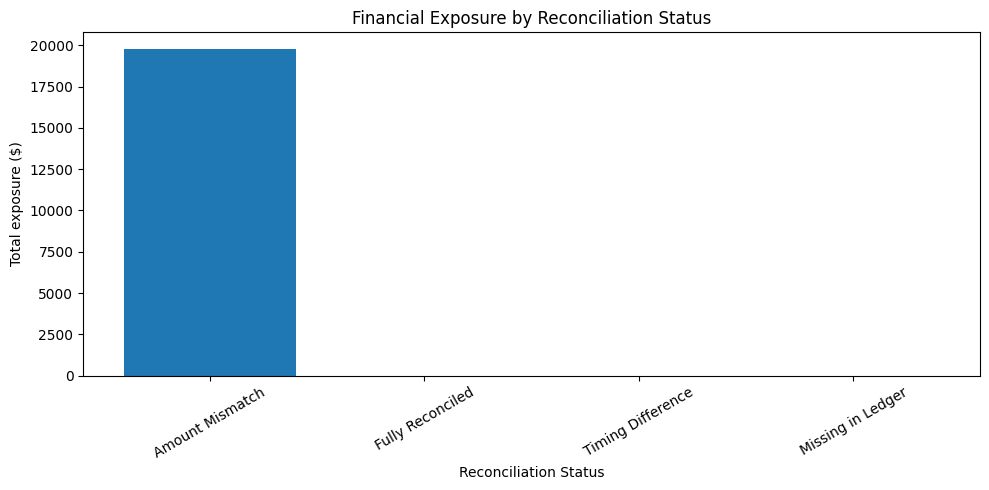

In [23]:
# Bar Chart Reconciliation status
import matplotlib.pyplot as plt

exposure_by_status_sorted = exposure_by_status.sort_values(
    "total_exposure", ascending=False
)
    
plt.figure(figsize=(10, 5))
plt.bar(
    exposure_by_status_sorted["recon_status"],
    exposure_by_status_sorted["total_exposure"]
)
plt.title("Financial Exposure by Reconciliation Status")
plt.xlabel("Reconciliation Status")
plt.ylabel("Total exposure ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

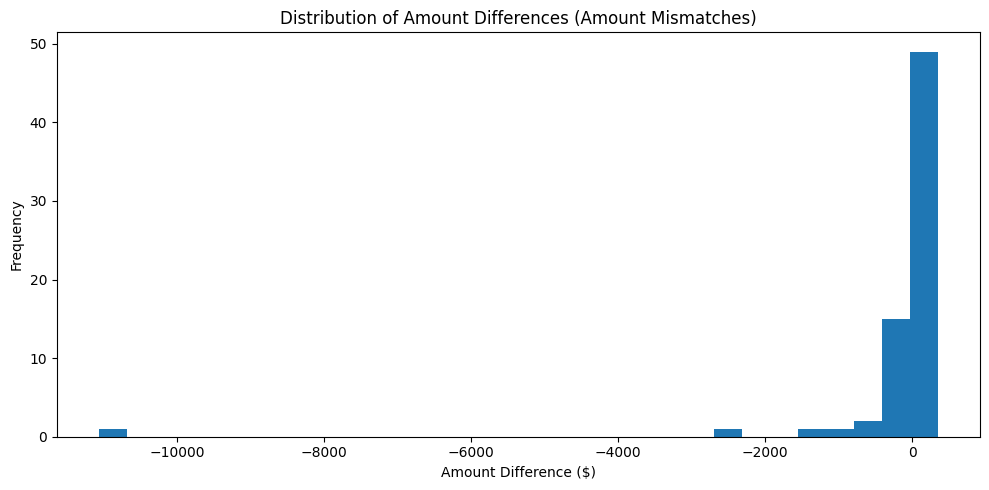

In [24]:
# Histogram of Amount Differences
mismatch_amounts = recon_full.loc[
    recon_full["recon_status"] == "Amount Mismatch",
    "amount_diff"
]

plt.figure(figsize=(10, 5))
plt.hist(mismatch_amounts, bins=30)
plt.title("Distribution of Amount Differences (Amount Mismatches)")
plt.xlabel("Amount Difference ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

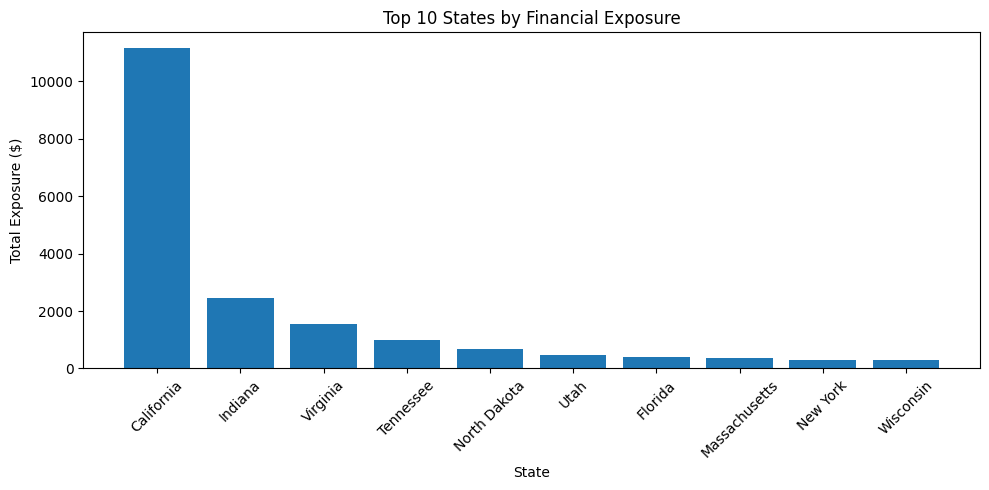

In [25]:
# Top 10 states by exposure
risk_by_state = (
    recon_full
    .groupby("state", as_index=False)
    .agg(
        total_exposure=("abs_amount_diff", "sum")
    )
    .sort_values("total_exposure", ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(
    risk_by_state.head(10)["state"],
    risk_by_state.head(10)["total_exposure"]
)
plt.title("Top 10 States by Financial Exposure")
plt.xlabel("State")
plt.ylabel("Total Exposure ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
kpi = {
    "Reconciliation Rate (%)": round(reconciled_rate, 2),
    "Unconciled Rate (%)": round(unreconciled_rate, 2),
    "Total Exposure ($)": round(total_unreconciled_exposure, 2),
    "Exposure as % of Revenue": round(exposure_pct_of_revenue, 2)
}

pd.DataFrame.from_dict(kpi, orient="index", columns=["Value"])

,Value
Reconciliation Rate (%),63.37
Unconciled Rate (%),36.63
Total Exposure ($),19795.56
Exposure as % of Revenue,1.03


In [27]:
recon_full.to_csv("reconciliation_dashboard_data.csv", index=False)